In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from category_encoders.cat_boost import CatBoostEncoder
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import os
import sys
root_path = str(Path(os.getcwd()).parent)
if root_path not in sys.path:
    sys.path.append(root_path)
import src.create_dataset as loader
import warnings
warnings.filterwarnings('ignore')

In [16]:
dataset = loader.create_dataset()

In [17]:
dataset_eda=dataset.copy()

In [18]:
dataset_eda.head()

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico,transactions,city,state,type,cluster,all_holidays
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,NaN,NaN,Quito,Pichincha,D,13,Primer dia del ano
1,1194,2013-01-01,42,CELEBRATION,0.0,0,NaN,NaN,Cuenca,Azuay,D,2,Primer dia del ano
2,1193,2013-01-01,42,BREAD/BAKERY,0.0,0,NaN,NaN,Cuenca,Azuay,D,2,Primer dia del ano
3,1192,2013-01-01,42,BOOKS,0.0,0,NaN,NaN,Cuenca,Azuay,D,2,Primer dia del ano
4,1191,2013-01-01,42,BEVERAGES,0.0,0,NaN,NaN,Cuenca,Azuay,D,2,Primer dia del ano


In [19]:
dataset_no_index = dataset
dataset = dataset.set_index('date')
dataset_index_na = dataset.dropna()

In [20]:
dataset_index_na

,id,store_nbr,family,sales,onpromotion,dcoilwtico,transactions,city,state,type,cluster,all_holidays
date,,,,,,,,,,,,
2013-01-02,2968,41,SCHOOL AND OFFICE SUPPLIES,0.000,0,93.14,915.0,Machala,El Oro,D,4,Work Day
2013-01-02,2969,41,SEAFOOD,8.000,0,93.14,915.0,Machala,El Oro,D,4,Work Day
2013-01-02,2954,41,HOME APPLIANCES,0.000,0,93.14,915.0,Machala,El Oro,D,4,Work Day
2013-01-02,2967,41,PRODUCE,0.000,0,93.14,915.0,Machala,El Oro,D,4,Work Day
2013-01-02,2961,41,MEATS,158.544,0,93.14,915.0,Machala,El Oro,D,4,Work Day
...,...,...,...,...,...,...,...,...,...,...,...,...
2017-08-15,2999698,25,SCHOOL AND OFFICE SUPPLIES,1.000,0,47.57,849.0,Salinas,Santa Elena,D,1,Work Day
2017-08-15,2999699,25,SEAFOOD,4.000,0,47.57,849.0,Salinas,Santa Elena,D,1,Work Day
2017-08-15,2999700,26,AUTOMOTIVE,3.000,0,47.57,534.0,Guayaquil,Guayas,D,10,Work Day


In [21]:
dataset.isna().sum()

id                   0
store_nbr            0
family               0
sales            28512
onpromotion          0
dcoilwtico      935550
transactions    274296
city                 0
state                0
type                 0
cluster              0
all_holidays         0
dtype: int64

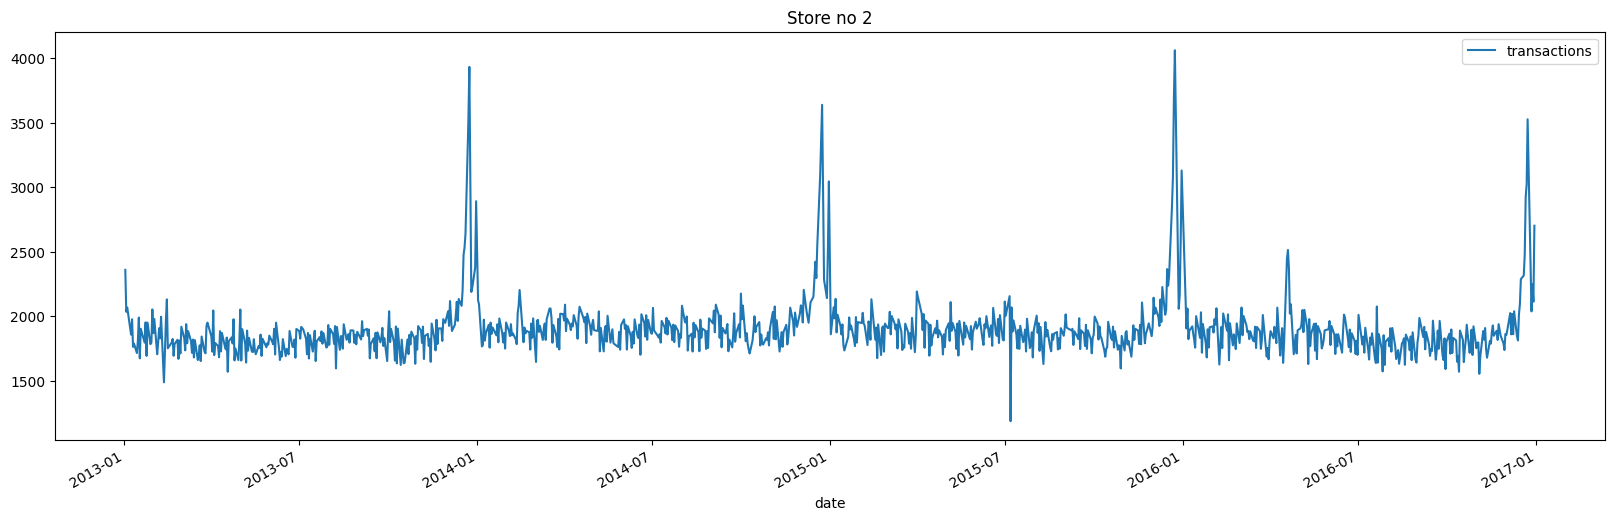

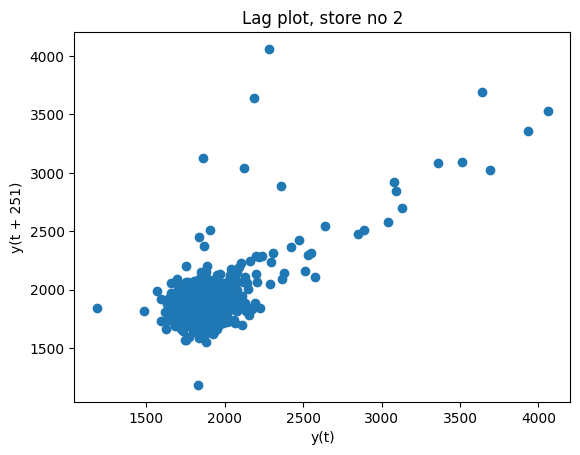

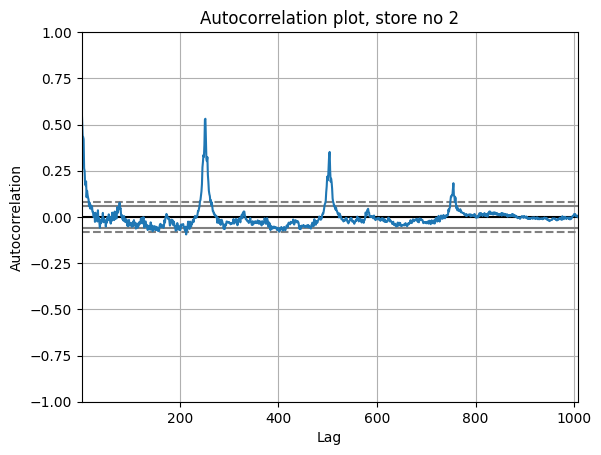

In [22]:
def get_store_autocorrelation_and_lag_plot(store_no,date_from,date_to):
    transactions_1 = dataset_index_na.loc[dataset_index_na['store_nbr'] == store_no, :].groupby(['date']).agg({
        'transactions': 'mean'
    })
    transactions_1[date_from:date_to].plot(figsize=(20, 6))
    plt.title(f"Store no {store_no}")
    plt.show()
def get_lag_plot(store_no,lag,date_from, date_to):
    transactions_1 = dataset_index_na.loc[dataset_index_na['store_nbr'] == store_no, :].groupby(['date']).agg({
        'transactions': 'mean'
    })
    pd.plotting.lag_plot(transactions_1[date_from:date_to],lag=lag)
    plt.title(f"Lag plot, store no {store_no}")
    plt.show()

def get_autocorrelation_plot(store_no,date_from,date_to):
    transactions_1 = dataset_index_na.loc[dataset_index_na['store_nbr'] == store_no, :].groupby(['date']).agg({
        'transactions': 'mean'
    })
    pd.plotting.autocorrelation_plot(transactions_1[date_from:date_to])
    plt.title(f"Autocorrelation plot, store no {store_no}")
    plt.show()
get_store_autocorrelation_and_lag_plot(2,'2013','2016')
get_lag_plot(2,251,'2013','2016')
get_autocorrelation_plot(2,'2013','2016')

In [23]:
dataset.isna().sum()

id                   0
store_nbr            0
family               0
sales            28512
onpromotion          0
dcoilwtico      935550
transactions    274296
city                 0
state                0
type                 0
cluster              0
all_holidays         0
dtype: int64

In [ ]:
def get_the_highest_peak(store_no, max_lag_value, transactions_1, ploting=False):
    from scipy.signal import find_peaks

    if ploting == True:
        get_autocorrelation_plot(store_no, '2013', '2016')

    max_lag = max_lag_value
    autocorrelations = np.array([transactions_1['transactions'].autocorr(lag) for lag in range(max_lag+1)])

    if ploting == True:
        plt.plot(range(max_lag+1), autocorrelations)
        plt.title(f"Autocorrelations until day {max_lag}")
        plt.xlabel('lag')
        plt.ylabel('Autocorrelation')
        plt.show()

    # find peaks:
    peaks, properties = find_peaks(autocorrelations, height=0)
    peak_lags = peaks
    peak_values = autocorrelations[peaks]
    max_peak_ind = -1
    max_peak_val = 0
    for lag, value in zip(peak_lags, peak_values):
        if value > max_peak_val:
            max_peak_val = value
            max_peak_ind = lag

    if ploting == True:
        print(f"Lag for max autocorrelation: {max_peak_ind}, value: {max_peak_val} considering years from 2013. to 2016:")
        pd.plotting.lag_plot(transactions_1, lag=max_peak_ind)

    return max_peak_ind, max_peak_val


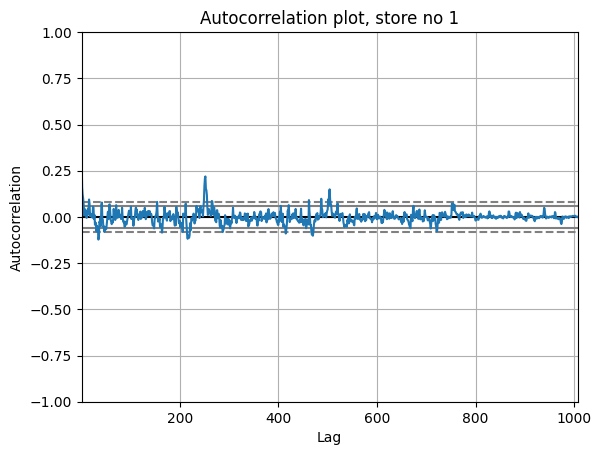

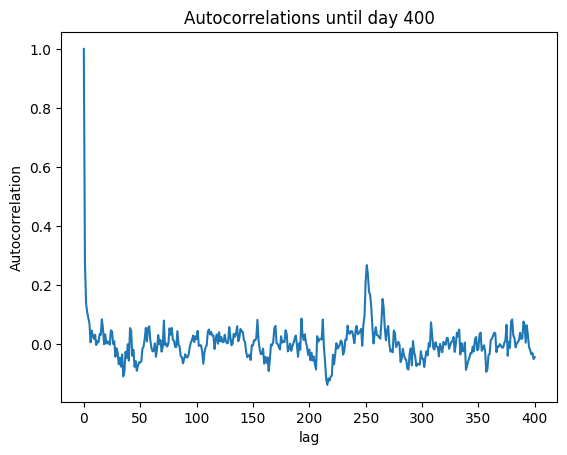

Lag for max autocorrelation: 251, value: 0.26769456563678184 considering years from 2013. to 2016:


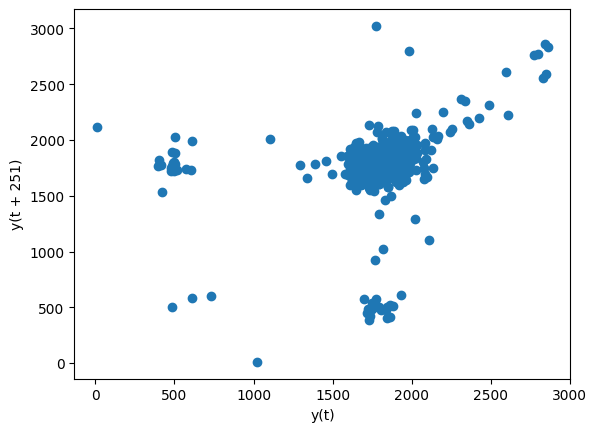

In [26]:
transactions_1 = dataset_index_na.loc[dataset_index_na['store_nbr'] == 1, :].groupby(['date']).agg({
    'transactions': 'mean'
})
lag, autocor = get_the_highest_peak(1,400,transactions_1,ploting=True)

ZAKLJUČAK: postoje prodavnice čiji se ciklus transakcija obnavlja na svakih 5 dana kao i prodavnice koje imaju maximalnu autokorelaciju za transakcije za zaostajanje lag = {250, 251, 252}. U skupu podataka ne postoje (kada je reč o transakcijama) statistički značajne negativne korelacije.

In [28]:
pip install plotly

^C
Note: you may need to restart the kernel to use updated packages.


   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.9 MB 9.9 MB/s eta 0:00:01
   ------------------------- -------------- 6.3/9.9 MB 19.3 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 23.5 MB/s  0:00:00

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwh

In [29]:
import plotly.express as px
subset = dataset.loc[dataset['store_nbr']==1,:]
fig = px.line(subset,x=subset.index,y=subset['transactions'], title='transactions with Slider')
fig.update_xaxes(
    rangeslider_visible = True,
    rangeselector = dict(
        buttons=list([
            dict(count=1,label='1y',step='year',stepmode='backward'),
            dict(count=2,label='2y',step='year',stepmode='backward'),
            dict(count=3,label='3y',step='year',stepmode='backward'),
            dict(step='all')
        ])
    )
)
fig.show()

In [ ]:
store_transactions_filled 

,store_nbr,transactions_filled
2013-01-01,1,0
2013-01-02,1,2111
2013-01-03,1,1833
2013-01-04,1,1863
2013-01-05,1,1509
...,...,...
2017-08-27,25,860.0
2017-08-28,25,951.0
2017-08-29,25,1007.0
2017-08-30,25,956.0


OIL nans

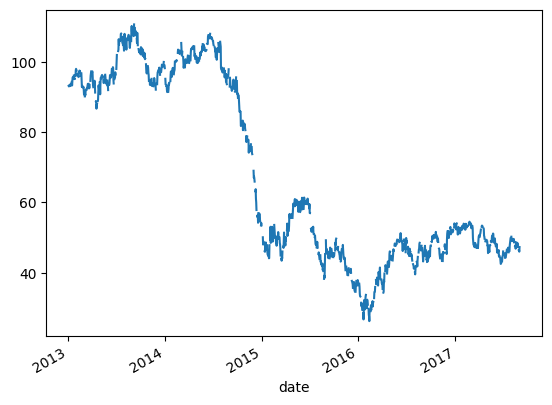

In [41]:
dataset['dcoilwtico'].plot()
plt.show()

In [ ]:
dataset['dcoilwtico'] = dataset['dcoilwtico'].interpolate(method='linear')
dataset['dcoilwtico'] = dataset['dcoilwtico'].bfill()

In [57]:
dataset.isna().sum()

date                       0
id                         0
store_nbr                  0
family                     0
sales                  28512
onpromotion                0
dcoilwtico              1782
city                       0
state                      0
type                       0
cluster                    0
all_holidays               0
transactions_filled        0
dtype: int64

In [44]:
store_transactions_filled = store_transactions_filled.reset_index()

In [45]:
store_transactions_filled.rename(columns={'index':'date'},inplace=True)

In [46]:
store_transactions_filled

,date,store_nbr,transactions_filled
0,2013-01-01,1,0
1,2013-01-02,1,2111
2,2013-01-03,1,1833
3,2013-01-04,1,1863
4,2013-01-05,1,1509
...,...,...,...
91795,2017-08-27,25,860.0
91796,2017-08-28,25,951.0
91797,2017-08-29,25,1007.0
91798,2017-08-30,25,956.0


In [47]:
dataset = pd.merge(dataset,store_transactions_filled,on=['date','store_nbr'])
dataset.drop(columns=['transactions'],inplace=True)

In [53]:
dataset.head()

,date,id,store_nbr,family,sales,onpromotion,dcoilwtico,city,state,type,cluster,all_holidays,transactions_filled
0,2013-01-01,0,1,AUTOMOTIVE,0.0,0,NaN,Quito,Pichincha,D,13,Primer dia del ano,0
1,2013-01-01,1194,42,CELEBRATION,0.0,0,NaN,Cuenca,Azuay,D,2,Primer dia del ano,0.0
2,2013-01-01,1193,42,BREAD/BAKERY,0.0,0,NaN,Cuenca,Azuay,D,2,Primer dia del ano,0.0
3,2013-01-01,1192,42,BOOKS,0.0,0,NaN,Cuenca,Azuay,D,2,Primer dia del ano,0.0
4,2013-01-01,1191,42,BEVERAGES,0.0,0,NaN,Cuenca,Azuay,D,2,Primer dia del ano,0.0


In [73]:
dataset.isna().sum()

date                       0
id                         0
store_nbr                  0
family                     0
sales                  28512
onpromotion                0
dcoilwtico                 0
city                       0
state                      0
type                       0
cluster                    0
all_holidays               0
transactions_filled        0
dtype: int64

In [58]:
dataset['all_holidays'].unique()

<StringArray>
[                         'Primer dia del ano',
                                    'Work Day',
                                    'Carnaval',
                          'Fundacion de Manta',
                         'Fundacion de Cuenca',
                   'Cantonizacion de Libertad',
                   'Cantonizacion de Riobamba',
                               'Viernes Santo',
                             'Dia del Trabajo',
                             'Dia de la Madre',
     'Cantonizacion del Puyo, Dia de la Madre',
                        'Batalla de Pichincha',
                   'Cantonizacion de Guaranda',
                        'Fundacion de Machala',
                  'Cantonizacion de Latacunga',
                  'Cantonizacion de El Carmen',
                  'Fundacion de Santo Domingo',
                    'Cantonizacion de Cayambe',
                      'Fundacion de Guayaquil',
                     'Fundacion de Esmeraldas',
               'Primer Gri

In [59]:
# Categorize the events
categories = {
    'Foundation_Provincialization_Independence': [
        'Fundacion de Manta', 'Provincializacion de Cotopaxi', 'Fundacion de Cuenca',
        'Cantonizacion de Libertad', 'Cantonizacion de Riobamba', 'Cantonizacion del Puyo',
        'Cantonizacion de Guaranda', 'Provincializacion de Imbabura', 'Cantonizacion de Latacunga',
        'Fundacion de Machala', 'Fundacion de Santo Domingo', 'Cantonizacion de El Carmen',
        'Cantonizacion de Cayam','Cantonizacion de Cayambe', 'Fundacion de Esmeraldas', 'Primer Grito de Independencia',
        'Fundacion de Riobamba', 'Fundacion de Ambato', 'Fundacion de Ibarra',
        'Cantonizacion de Quevedo', 'Independencia de Guayaquil', 'Traslado Independencia de Guayaquil',
        'Cantonizacion de Salinas', 'Independencia de Cuenca', 'Provincializacion de Santo Domingo',
        'Provincializacion Santa Elena', 'Independencia de Guaranda', 'Independencia de Latacunga',
        'Independencia de Ambato', 'Fundacion de Quito-1', 'Fundacion de Quito', 'Fundacion de Loja',
        'Traslado Fundacion de Guayaquil', 'Traslado Primer Grito de Independencia',
        'Traslado Fundacion de Quito', 'Fundacion de Guayaquil-1', 'Fundacion de Guayaquil'
],
'Holidays': [
    'Navidad-4','Dia de Difuntos', 'Navidad-3', 'Navidad-2', 'Puente Navidad',
    'Navidad-1', 'Navidad', 'Navidad+1', 'Puente Primer dia del ano', 'Primer dia del ano-1',
    'Primer dia del ano', 'Recupero puente Navidad', 'Recupero puente primer dia del ano',
    'Carnaval', 'Viernes Santo', 'Dia del Trabajo', 'Dia de la Madre-1', 'Dia de la Madre',
    'Batalla de Pichincha','Traslado Batalla de Pichincha',
    'Recupero Puente Navidad', 'Recupero Puente Primer dia del ano',
    'Puente Dia de Difuntos', 'Recupero Puente Dia de Difuntos','Traslado Primer dia del ano'
],
'Entertainment': [
    'Inauguracion Mundial de futbol Brasil', 'Mundial de futbol Brasil: Ecuador-Suiza',
    'Mundial de futbol Brasil: Ecuador-Honduras', 'Mundial de futbol Brasil: Ecuador-Francia',
    'Mundial de futbol Brasil: Octavos de Final', 'Mundial de futbol Brasil: Cuartos de Final',
    'Mundial de futbol Brasil: Semifinales', 'Mundial de futbol Brasil: Tercer y cuarto lugar',
    'Mundial de futbol Brasil: Final','Black Friday','Cyber Monday'
],
'Earthquake': [
    'Terremoto Manabi', 'Terremoto Manabi+1', 'Terremoto Manabi+2', 'Terremoto Manabi+3',
    'Terremoto Manabi+4', 'Terremoto Manabi+5', 'Terremoto Manabi+6', 'Terremoto Manabi+7',
    'Terremoto Manabi+8', 'Terremoto Manabi+9', 'Terremoto Manabi+10', 'Terremoto Manabi+11',
    'Terremoto Manabi+12', 'Terremoto Manabi+13', 'Terremoto Manabi+14', 'Terremoto Manabi+15',
    'Terremoto Manabi+16', 'Terremoto Manabi+17', 'Terremoto Manabi+18', 'Terremoto Manabi+19',
    'Terremoto Manabi+20', 'Terremoto Manabi+21', 'Terremoto Manabi+22', 'Terremoto Manabi+23',
    'Terremoto Manabi+24', 'Terremoto Manabi+25', 'Terremoto Manabi+26', 'Terremoto Manabi+27',
    'Terremoto Manabi+28', 'Terremoto Manabi+29', 'Terremoto Manabi+30'
]
}

In [52]:
def categorize_event(event):
    for category, events_list in categories.items():
        if event in events_list:
            return category
    return 'Other'

In [60]:
dataset['all_holidays'] = dataset['all_holidays'].apply(categorize_event)
#da mi bude lakse u modelima

In [61]:
dataset.head()

,date,id,store_nbr,family,sales,onpromotion,dcoilwtico,city,state,type,cluster,all_holidays,transactions_filled
0,2013-01-01,0,1,AUTOMOTIVE,0.0,0,NaN,Quito,Pichincha,D,13,Holidays,0
1,2013-01-01,1194,42,CELEBRATION,0.0,0,NaN,Cuenca,Azuay,D,2,Holidays,0.0
2,2013-01-01,1193,42,BREAD/BAKERY,0.0,0,NaN,Cuenca,Azuay,D,2,Holidays,0.0
3,2013-01-01,1192,42,BOOKS,0.0,0,NaN,Cuenca,Azuay,D,2,Holidays,0.0
4,2013-01-01,1191,42,BEVERAGES,0.0,0,NaN,Cuenca,Azuay,D,2,Holidays,0.0


In [62]:
dataset['date']=pd.to_datetime(dataset['date'])

In [63]:
dataset['transactions_filled']=dataset['transactions_filled'].astype('int')

In [ ]:
from datetime import datetime, timedelta
def is_payday(day):
    next_day = day + timedelta(days=1)
    if day == 15:
        return True

    if next_day.month != day.month:
        return True

    return False

def is_earthquake_impact(date, weeks=3):
    earthquake_date = pd.Timestamp('2016-04-16')
    impact_period_end = earthquake_date + pd.Timedelta(weeks=weeks)
    return date >= impact_period_end

In [ ]:
dataset['is_payday']=dataset['date'].apply(is_payday )
dataset['is_impacted_by_earthquake']=dataset['date'].apply(is_earthquake_impact)

In [ ]:
X_train=dataset.loc[dataset.date.dt.year<2017,:]
X_train=X_train.set_index('date')
X_test=dataset.loc[dataset.date.dt.year>=2017,:]
X_test=X_test.set_index('date')
y_train = X_train.sales
y_test=X_test.sales
X_train = X_train.drop(['sales'], axis=1)
X_test = X_test.drop(['sales'], axis=1)
dataset=dataset.set_index('date')
y=dataset['sales']
X=dataset.drop(['sales'], axis=1)

In [ ]:
#mislim da stavim lagove za transakcije ako neki ispadne normalan
#ali posto imam dataset sa nedeljama nmg sad
import statsmodels.api as sm
a = X_train.groupby(["date", "family"]).transactions_filled.mean().reset_index().set_index("date")

# Iterate over unique families
for num, i in enumerate(a.family.unique()):
    try:
        fig, ax = plt.subplots(1, 2, figsize=(15, 5))
        temp = a[a.family == i]

        # Plot Autocorrelation
        sm.graphics.tsa.plot_acf(temp.transactions_filled, lags=400, ax=ax[0], title="AUTOCORRELATION\n" + i)

        # Plot Partial Autocorrelation
        sm.graphics.tsa.plot_pacf(temp.transactions_filled, lags=400, ax=ax[1], title="PARTIAL AUTOCORRELATION\n" + i)

        plt.show()  # Show the plot for each family
    except Exception as e:
        print(f"Error plotting for {i}: {str(e)}")
#najznacajnije su ove prve autokorelacije

In [ ]:
for num, i in enumerate(a.family.unique()):
    try:
        fig, ax = plt.subplots(1, 2, figsize=(15, 5))
        temp = a[a.family == i]

        # Plot Autocorrelation
        sm.graphics.tsa.plot_acf(temp.transactions_filled, lags=40, ax=ax[0], title="AUTOCORRELATION\n" + i)

        # Plot Partial Autocorrelation
        sm.graphics.tsa.plot_pacf(temp.transactions_filled, lags=40, ax=ax[1], title="PARTIAL AUTOCORRELATION\n" + i)

        plt.show()  # Show the plot for each family
    except Exception as e:
        print(f"Error plotting for {i}: {str(e)}")
#najznacajnije su ove prve autokorelacije

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
# pogledajmo kako se model ponasa kad se dodaju lagovi za koje smo videli da su znacajni ranije
#za  lagove 1 3 6 12 deluje mi da su najznacajniji
data=X_trainf.reset_index()
data['lag_1'] = data['transactions_filled'].shift(1)
data['lag_3'] = data['transactions_filled'].shift(3)
data['lag_6'] = data['transactions_filled'].shift(6)
data['lag_12'] = data['transactions_filled'].shift(12)
# Drop missing values created by lag features
data = data.dropna()

# Features and target
X = data[['lag_1','lag_3','lag_6','lag_12']]
y = y_trainf

# Time series split
tscv = TimeSeriesSplit(n_splits=5)
model = LinearRegression()

# Store results
results = []

for train_index, test_index in tscv.split(X):
    X_train2, X_test2 = X.iloc[train_index], X.iloc[test_index]
    y_train2, y_test2 = y.iloc[train_index], y.iloc[test_index]

    # Fit the model
    model.fit(X_train2, y_train2)

    # Predict
    y_pred = model.predict(X_test2)

    # Calculate and store the performance metric
    mse = mean_squared_error(y_test2, y_pred)
    r2 = r2_score(y_test2, y_pred)
    results.append(r2)

    # Plot the actual vs predicted values
    plt.figure(figsize=(10, 6))
    plt.plot(y_test2.index, y_test2, marker='.', label='Actual Sales')
    plt.plot(y_test2.index, y_pred, marker='.', label='Predicted Sales')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.title('Actual vs Predicted Sales')
    plt.legend()
    plt.show()

# Print the results
print("Mean Squared Error for each fold:", results)
print("Average R squared:", np.mean(results))

#vrlo losi podaci ne moze se nista ovo ubaciti

In [ ]:
b = X_trainf.groupby(["date"]).dcoilwtico.mean().reset_index().set_index("date")
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sm.graphics.tsa.plot_acf(b.dcoilwtico, lags=400, ax=ax[0], title="AUTOCORRELATION\n")
sm.graphics.tsa.plot_pacf(b.dcoilwtico, lags=400, ax=ax[1], title="PARTIAL AUTOCORRELATION\n")

plt.show()
#samo na samom pocetku vrlo jaka

In [ ]:
import plotly.express as px
a = dataset.groupby("family").sales.mean().sort_values(ascending = False).reset_index()
px.bar(a, y = "family", x="sales", color = "family", title = "Top product families")

In [ ]:
train=train.reset_index()
train["year"] = train.date.dt.year
px.line(train.groupby(["city", "year"]).sales.mean().reset_index(), x = "year", y = "sales", color = "city")

In [ ]:
#gradovi puyo i quito vidi njohove promocije
city_name = 'Quito'
train_city = train[train['city'] == city_name]

# Calculate mean on-promotion levels by product family
family_onpromotion = train_city.groupby('family')['onpromotion'].mean().sort_values()

# Plotting
plt.figure(figsize=(12, 6))
family_onpromotion.plot(kind='bar')
plt.title(f'Mean On Promotion by Product Family - {city_name}')
plt.xlabel('Product Family')
plt.ylabel('Mean On Promotion')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.tight_layout()
plt.show()
#slicno

In [ ]:
#i onda cu pogledati za minimalni i maximalni ima li neke razlike negde i onda interaction term
#ako se ne ponasa kako treba
number = 1
train_city = train[train['store_nbr'] == number]

# Calculate mean on-promotion levels by product family
family_onpromotion = train_city.groupby('family')['onpromotion'].mean().sort_values()

# Plotting
plt.figure(figsize=(12, 6))
family_onpromotion.plot(kind='bar')
plt.title(f'Mean On Promotion by store - {number}')
plt.xlabel('Product Family')
plt.ylabel('Mean On Promotion')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.tight_layout()
plt.show()

In [ ]:
number = 44
train_city = train[train['store_nbr'] == number]

# Calculate mean on-promotion levels by product family
family_onpromotion = train_city.groupby('family')['onpromotion'].mean().sort_values()

# Plotting
plt.figure(figsize=(12, 6))
family_onpromotion.plot(kind='bar')
plt.title(f'Mean On Promotion by store - {number}')
plt.xlabel('Product Family')
plt.ylabel('Mean On Promotion')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.tight_layout()
plt.show()
#isto nemaa nikakve skrivene interakcije

In [ ]:
X_dropped.columns
num_cols=['onpromotion','transactions_filled','day_of_year','season','lag_1']

In [ ]:
X_dropped['sales']=y_trainf

In [ ]:
X_dropped.columns

sns.pairplot(X_dropped)

In [ ]:
X_new=X_dropped.reset_index()

In [ ]:
X_new=X_new.groupby('date').mean()
sns.pairplot(X_new)
#nista nije ni linearno a ni polinomijalno

In [ ]:
filtered_df = dataset[(dataset['store_nbr'] == 44) & (dataset['family'] == "BEVERAGES")]

grouped_mean_df = filtered_df.groupby('date')[['onpromotion', 'cluster', 'transactions_filled', 'is_impacted_by_earthquake', 'sales']].mean().reset_index()

sns.pairplot(grouped_mean_df)

In [ ]:
filtered_df = dataset[(dataset['store_nbr'] == 44) & (dataset['family'] == "MEATS")]
grouped_mean_df = filtered_df.groupby('date')[['onpromotion', 'cluster', 'transactions_filled', 'is_impacted_by_earthquake', 'sales']].mean().reset_index()
sns.pairplot(grouped_mean_df)
#nema ni linearne veze cak